In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [22]:
df1 = pd.read_csv("./Social_Network_Ads.csv")

In [23]:
df1.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [25]:
df2 = df1.iloc[:, 2:]
df2.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [27]:
df2.sample(5)

,Age,EstimatedSalary,Purchased
35,35,27000,0
174,34,72000,0
383,49,28000,1
336,58,144000,1
74,32,18000,0


In [28]:
df2.tail(5)

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [31]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- --------------------------

In [32]:
# Scaling the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df2.drop("Purchased", axis=1), df2["Purchased"], test_size=0.3, random_state=42)



In [34]:
X_train.shape, X_test.shape

((280, 2), (120, 2))

In [ ]:
X_train.head(3)
# x data are the input features

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000


In [ ]:
y_train.head(3)
# y data are the target feature

157    0
109    0
17     1
Name: Purchased, dtype: int64

standardScaler

In [40]:
from sklearn.preprocessing import StandardScaler
standardScaler = StandardScaler()

# fit the scaler to the training data, it will learn parameters
standardScaler.fit(X_train)

# transform train and test data
X_train_scaled = standardScaler.transform(X_train)
X_test_scaled = standardScaler.transform(X_test)

In [41]:
standardScaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [ ]:
X_train_scaled
# converted to numpy array, we can convert it back to dataframe if we want

array([[-0.84252154,  0.1301563 ],
       [ 0.04175763,  0.2777019 ],
       [ 0.72953032, -1.31579061],
       [ 1.61380949,  1.10395728],
       [ 0.82778356, -1.40431797],
       [-1.43204099, -1.25677236],
       [-0.05649561,  0.1301563 ],
       [ 0.43477059, -0.16493491],
       [-0.2530021 ,  0.01211982],
       [ 1.31904976,  2.22530386],
       [ 0.14001087,  0.74984783],
       [-1.33378775,  0.54328399],
       [ 2.00682245,  0.72033871],
       [-1.23553451, -1.43382709],
       [ 0.33651735, -0.34198963],
       [-0.94077478,  0.54328399],
       [ 0.43477059,  0.2777019 ],
       [ 0.43477059,  1.10395728],
       [ 0.82778356,  0.74984783],
       [ 0.9260368 ,  1.25150288],
       [-0.44950858, -1.25677236],
       [-1.82505395, -1.34529973],
       [ 1.12254328,  0.54328399],
       [-0.64601506, -1.64039093],
       [-0.7442683 ,  0.24819278],
       [ 1.02429004,  2.07775825],
       [-0.54776182,  1.36953936],
       [-0.05649561,  0.01211982],
       [-1.9233072 ,

In [43]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [44]:
X_train_scaled

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318
...,...,...
275,-1.333788,-1.286281
276,-1.137281,-1.050209
277,0.533024,1.841685
278,0.140011,0.189175


In [45]:
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.575000,70589.285714
std,10.196005,33948.504534
min,18.000000,15000.000000
25%,30.000000,44000.000000
50%,37.000000,71000.000000
75%,45.000000,88000.000000
max,60.000000,150000.000000


In [46]:
np.round(X_train.describe(), 2)

,Age,EstimatedSalary
count,280.00,280.00
mean,37.58,70589.29
std,10.20,33948.50
min,18.00,15000.00
25%,30.00,44000.00
50%,37.00,71000.00
75%,45.00,88000.00
max,60.00,150000.00


In [ ]:
np.round(X_train_scaled.describe(), 2)
# after scaling, the mean is 0 and std is 1 for all features, this is what standardization does.

,Age,EstimatedSalary
count,280.00,280.00
mean,-0.00,0.00
std,1.00,1.00
min,-1.92,-1.64
25%,-0.74,-0.78
50%,-0.06,0.01
75%,0.73,0.51
max,2.20,2.34


Effect of Scaling on the data

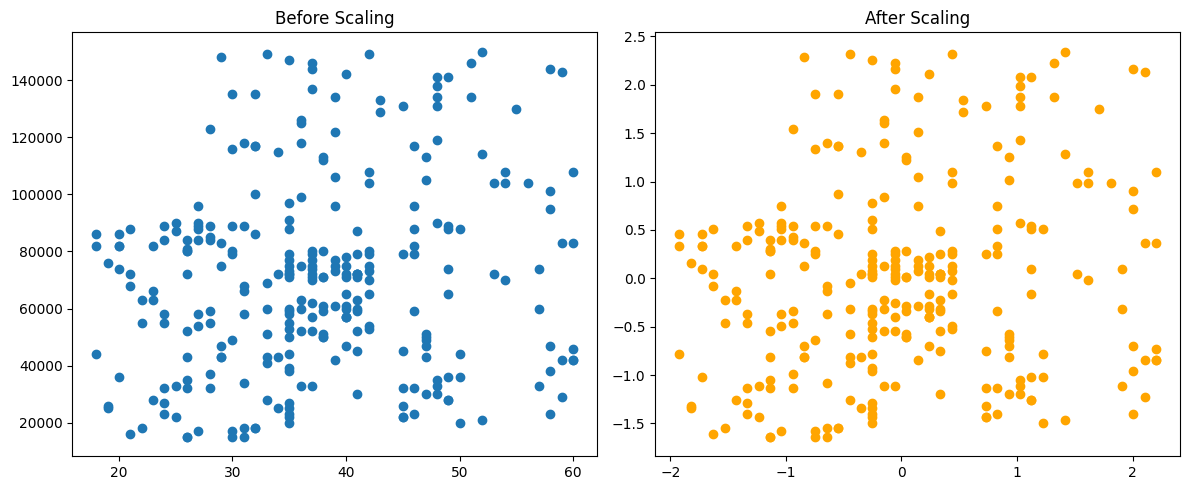

In [ ]:
fig,(gx1, gx2) = plt.subplots(1, 2, figsize=(12, 5))
gx1.scatter(X_train["Age"], X_train["EstimatedSalary"])
gx1.set_title("Before Scaling")
gx2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"], color="orange")
gx2.set_title("After Scaling")

plt.tight_layout()
plt.show()

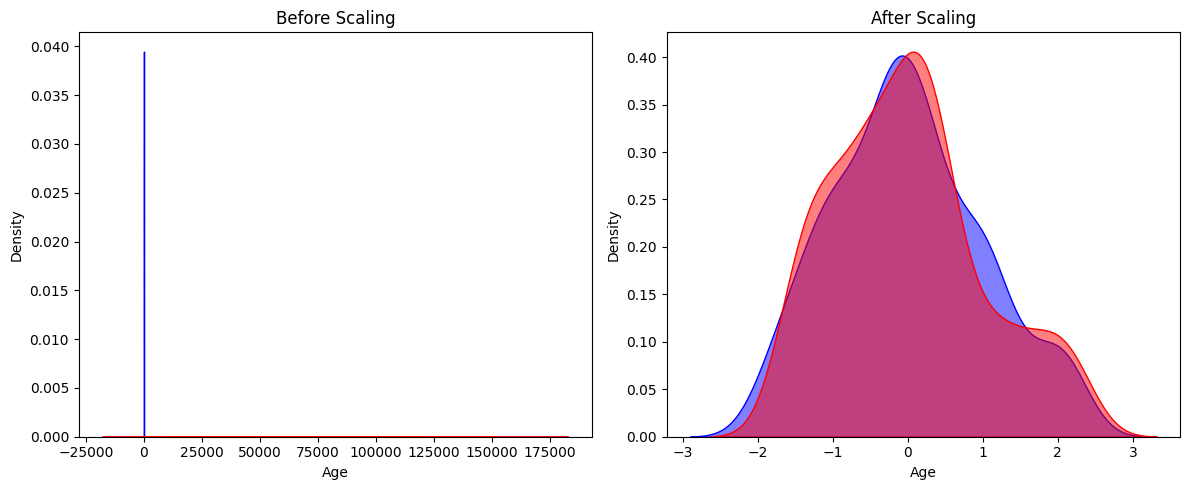

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before Scaling
sns.kdeplot(X_train["Age"], ax=ax1, fill=True, color="blue", alpha=0.5)
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1, fill=True, color="red", alpha=0.5)
ax1.set_title("Before Scaling")
# After Scaling
sns.kdeplot(X_train_scaled["Age"], ax=ax2, fill=True, color="blue", alpha=0.5)
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2, fill=True, color="red", alpha=0.5)
ax2.set_title("After Scaling")
plt.tight_layout()
plt.show()

comparison of distribution of features before and after scaling

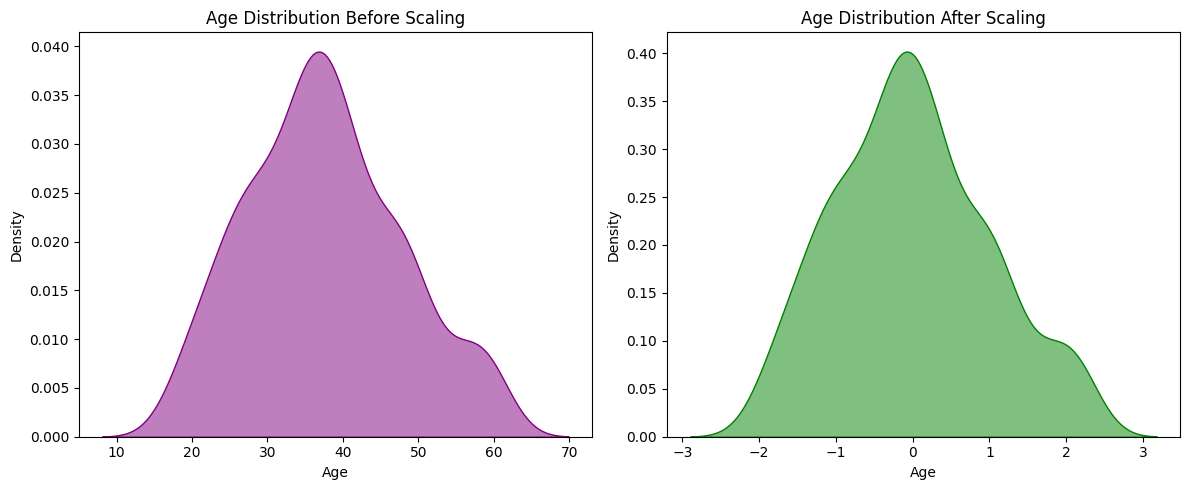

In [63]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1, fill=True, color="purple", alpha=0.5)
ax2.set_title("Age Distribution After Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2, fill=True, color="green", alpha=0.5)
plt.tight_layout()
plt.show()

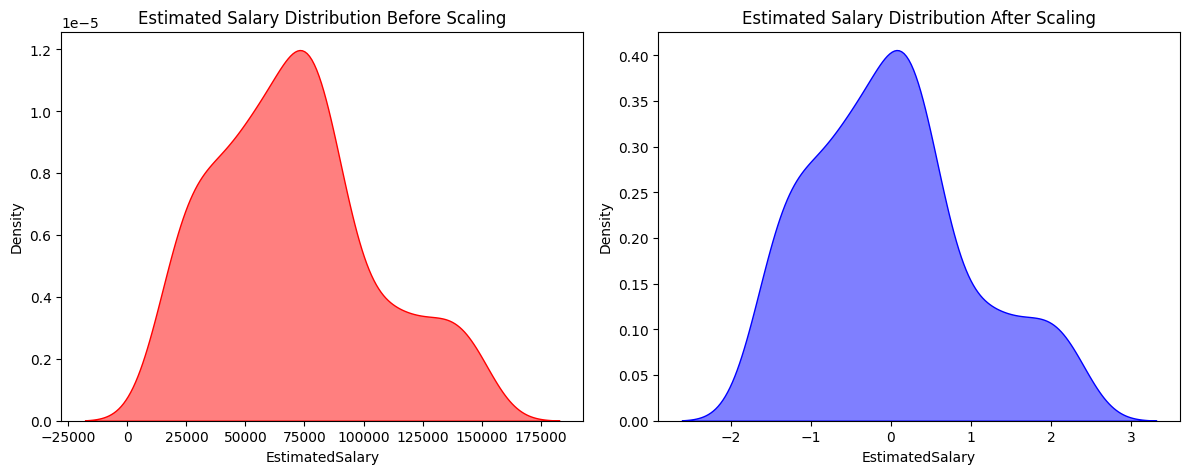

In [76]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1, fill=True, color="red", alpha=0.5)
ax1.set_title("Estimated Salary Distribution Before Scaling")

# after scaling
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2, fill=True, color="blue", alpha=0.5)
ax2.set_title("Estimated Salary Distribution After Scaling")
plt.tight_layout()
plt.show()

Why scaling is important?

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
lr=LogisticRegression()
lr_scaled = LogisticRegression()

In [70]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [83]:
from sklearn.metrics import accuracy_score, classification_report

In [80]:
print("Accuracy before scaling:", accuracy_score(y_test, y_pred))
print("Accuracy after scaling:", accuracy_score(y_test, y_pred_scaled))

Accuracy before scaling: 0.85
Accuracy after scaling: 0.85


In [86]:
df2.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


effect of outliers

In [88]:
neeData=pd.DataFrame({
    "Age": [5,10,95],
    "EstimatedSalary": [10000, 50000, 200000],
    "Purchased": [0, 1, 1]
})
df3=pd.concat([df2, neeData], ignore_index=True)

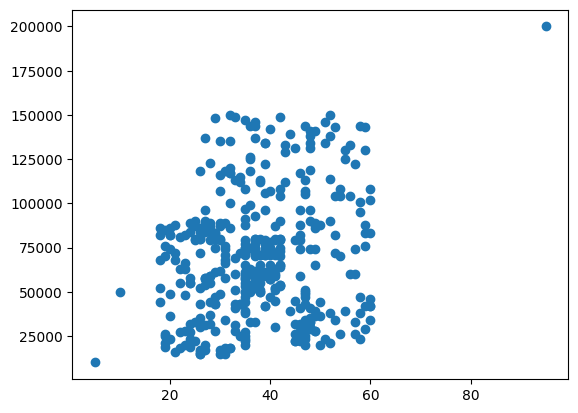

In [89]:
plt.scatter(df3["Age"], df3["EstimatedSalary"])

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [84]:
dt=DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [90]:
lr=LogisticRegression()
lr_scaled = LogisticRegression()